In [1]:
import numpy as np
import torch
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

### prepare the dataset for the stock prices

In [2]:
# Downdload the Apple stock prices from 2020-01-01 to 2026-01-01
response = yf.download('AAPL',start='2020-01-01',end='2026-01-01')

[*********************100%***********************]  1 of 1 completed


In [3]:
prices = response['Close'].values
print(prices.shape)
print(prices.ndim)

(1508, 1)
2


In [4]:
# convert the dataset 2D->1D
prices = prices.squeeze(1)

In [5]:
print(prices.ndim)

1


In [6]:
print(prices.max())
print(prices.min())

285.4131164550781
54.11703872680664


### Data Preprocessing

In [7]:
# Scale the Data Using the Normalization
# (price - min(price)) / (max(price) - min(price))
minimum_price = prices.min()
maximum_price = prices.max()

prices_normalized = (prices - minimum_price) / (maximum_price - minimum_price)

In [8]:
print(prices_normalized)

[0.07849037 0.07545261 0.07791814 ... 0.94640532 0.94347318 0.93821293]


C:\Users\Hp\AppData\Local\Temp\ipykernel_6860\1054826592.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(combined_data,labels=['Before Normalization','After Normalization'],patch_artist=True)


{'whiskers': [<matplotlib.lines.Line2D at 0x2925d6a3770>,
 'caps': [<matplotlib.lines.Line2D at 0x2925d6a3a10>,
 'boxes': [<matplotlib.patches.PathPatch at 0x2925d6a3380>,
 'medians': [<matplotlib.lines.Line2D at 0x2925d6a3cb0>,
 'fliers': [<matplotlib.lines.Line2D at 0x2925d6a3e00>,
 'means': []}

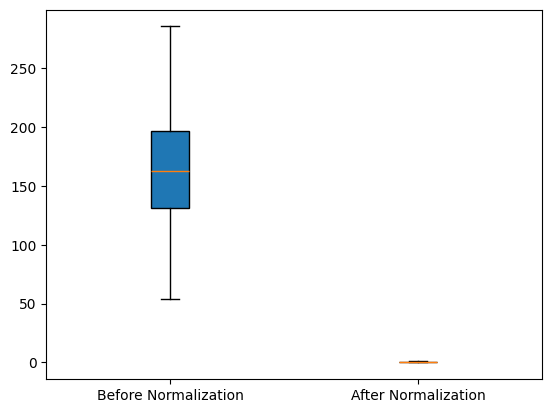

In [9]:
combined_data = [prices,prices_normalized]
plt.boxplot(combined_data,labels=['Before Normalization','After Normalization'],patch_artist=True)

### Genrate the Data

In [10]:
# sequence length used to genrate x and y
SEQUENCE_LENGTH = 20

In [20]:
x = []
y = []

In [21]:
for index in range(len(prices_normalized)-SEQUENCE_LENGTH):
    x.append(prices_normalized[index:index+SEQUENCE_LENGTH])
    y.append(prices_normalized[index+SEQUENCE_LENGTH])
x = np.array(x)
y = np.array(y)
# convert the x and y to tensors
x = torch.tensor(x,dtype=torch.float32)
y = torch.tensor(y,dtype=torch.float32)

In [22]:
print(f"Shape of input : {x.shape} Shape of ouput {y.shape}")

Shape of input : torch.Size([1488, 20]) Shape of ouput torch.Size([1488])


### DEfine the Model

In [23]:
x = x.unsqueeze(-1)  # shape becomes torch.Size([983, 20, 1])
y = y.unsqueeze(-1)  # shape becomes torch.Size([983, 1])
class StockPricePrediction(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = torch.nn.LSTM(
            input_size = 1,
            hidden_size = 40,
            batch_first = True
        )
        self.linear = torch.nn.Linear(40,1)
    def forward(self,x):
        output,(hidden,cell) = self.lstm(x)
        hidden = hidden[-1]
        output = self.linear(hidden)
        return output

### Create the model and define the Hyperparameters

In [24]:
model = StockPricePrediction()

### Define the Hyper parameters

In [25]:
epochs = 500
loss_function = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.01)

### Training Loop

In [26]:
device=''
if torch.cuda.is_available():
    device='cuda'
else:
    device='cpu'

In [27]:
x=x.to(device)
y=y.to(device)
model=model.to(device)

In [28]:
total_loss = 0
for epoch in range(epochs):
    prediction = model(x)
    loss = loss_function(prediction,y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (epoch+1) %50 ==0:
        print(f"epoch : {epoch+1}, loss : {loss}")

epoch : 50, loss : 0.0006484649493359029
epoch : 100, loss : 0.0003479805018287152
epoch : 150, loss : 0.00032389795524068177
epoch : 200, loss : 0.00031160557409748435
epoch : 250, loss : 0.0003004765894729644
epoch : 300, loss : 0.00029042555252090096
epoch : 350, loss : 0.0002812960301525891
epoch : 400, loss : 0.00027291482547298074
epoch : 450, loss : 0.0002651256218086928
epoch : 500, loss : 0.0002578077546786517


### Test the model by predicting next day stock price

In [29]:
# get the last sequence only
last_sequence = prices_normalized[-SEQUENCE_LENGTH:]
last_sequence = (torch.tensor(last_sequence,dtype=torch.float32)).to(device)

In [30]:
last_sequence.unsqueeze_(0).unsqueeze_(-1)
last_sequence.ndim

3

In [31]:
with torch.no_grad():
    prediction = model(last_sequence)
    print(prediction)

tensor([[0.9418]], device='cuda:0')


In [32]:
print(prices[-5:])

[273.06671143 272.65783691 273.01687622 272.33868408 271.12200928]


### Plot the Prediction

In [33]:
prediction_numpy=[]
with torch.no_grad():
    for i in x:
        i = i.to(device)
        i.unsqueeze_(0)
        prediction = model(i)
        prediction_numpy.append(prediction.cpu())

In [34]:
len(prediction_numpy)

1488

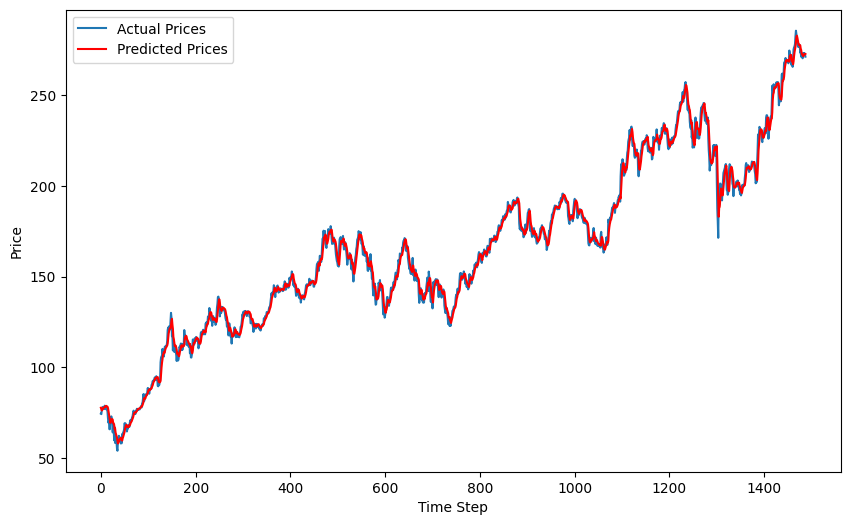

In [35]:
# Convert predictions back to original stock price scale
predictions_scaled = np.array(prediction_numpy).squeeze() * (maximum_price - minimum_price) + minimum_price

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(prices[20:], label='Actual Prices')
plt.plot(predictions_scaled, color='red', label='Predicted Prices')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.legend()
plt.show()